<a href="https://colab.research.google.com/github/mcrowley19/Toy-Models-for-Superposition-Implementation/blob/main/toy_models_of_superposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [106]:

import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(12345)

class LinearToyModel(nn.Module):
  # Parameters from the paper: n = 20, m = 5, I_i = 0.7 ** i
  # Note: Some of these parameters differ for certain graphs
  def __init__(self, n= 20, m=5):
    super().__init__()
    self.n = n
    self.W = nn.Parameter(torch.randn((m,n)))
    self.b = nn.Parameter(torch.randn((n,)))
    self.i = 0.7 ** torch.arange(self.n)


# Generating a sparse tensor of random values between 0 and 1 where only 10% of values are > 0
  def forward(self, x):
    h = self.W @ x # Encoder
    x2 = self.W.transpose(0,1) @ h + self.b
    return x2

  def generate_data(self):
    x = torch.zeros(self.n,)
    y = torch.rand(self.n,)
    mask = y > 0.9
    x[mask] = 1
    x = x * torch.rand(self.n,)
    return x


In [107]:

class ReLUToyModel(nn.Module):
  # Parameters from the paper: n = 20, m = 5, I_i = 0.7 ** i
  def __init__(self, m=5, n=20):
    super().__init__()
    self.n = n
    self.W = nn.Parameter(torch.randn((m,n)))
    self.b = nn.Parameter(torch.zeros((n,)))
    self.i = 0.7 ** torch.arange(n)


# Generating a sparse tensor of random values between 0 and 1 where only 10% of values are > 0
  def forward(self, x):
    h = self.W @ x # Encoder
    nonlin = nn.ReLU()
    x2 = nonlin(self.W.transpose(0,1) @ h + self.b)
    return x2

  def generate_data(self):
    x = torch.zeros(self.n,)
    y = torch.rand(self.n,)
    mask = y > 0.9
    x[mask] = 1
    x = x * torch.rand(self.n,)
    return x

In [108]:
def train(model):
  optim = torch.optim.AdamW([model.W, model.b], lr=1e-2)

  for step in range(10000):
    optim.zero_grad()
    batch = model.generate_data()
    out = model(batch)
    loss = sum(model.i*(batch - out) ** 2)

    loss.backward()
    optim.step()
    if step % 1000 == 0:
      print("loss: ",loss)


In [109]:
if torch.cuda.is_available():
  DEVICE = 'cuda'
else:
  DEVICE = 'cpu'


In [113]:
# Code for this  mostly taken verbatim from Anthropic's implementation.
# I have decided to only train one model however for simplification

def intro_diagram(model):
  from matplotlib import colors  as mcolors
  from matplotlib import collections  as mc
  WA = model.W.detach()
  plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.viridis(model.i.cpu().numpy()))
  plt.rcParams['figure.dpi'] = 200
  N = len(WA[:,0])
  W = WA.cpu().detach().numpy().T
  fig, ax = plt.subplots(figsize=(2,2))
  colors = [mcolors.to_rgba(c)
            for c in plt.rcParams['axes.prop_cycle'].by_key()['color']]
  ax.scatter(W[:,0], W[:,1], c=colors[0:len(W[:,0])])
  ax.add_collection(mc.LineCollection(np.stack((np.zeros_like(W),W), axis=1), colors=colors))
  z = 1.5
  ax.set_facecolor('#FCFBF8')
  ax.set_xlim((-z,z))
  ax.set_ylim((-z,z))
  ax.tick_params(left = True, right = False , labelleft = False ,
                  labelbottom = False, bottom = True)
  for spine in ['top', 'right']:
      ax.spines[spine].set_visible(False)
  for spine in ['bottom','left']:
      ax.spines[spine].set_position('center')
  plt.show()



loss:  tensor(6.4999, grad_fn=<AddBackward0>)
loss:  tensor(0.0022, grad_fn=<AddBackward0>)
loss:  tensor(0.0028, grad_fn=<AddBackward0>)
loss:  tensor(0.0040, grad_fn=<AddBackward0>)
loss:  tensor(0.3421, grad_fn=<AddBackward0>)
loss:  tensor(0.0045, grad_fn=<AddBackward0>)
loss:  tensor(0.0988, grad_fn=<AddBackward0>)
loss:  tensor(0.0537, grad_fn=<AddBackward0>)
loss:  tensor(0.0037, grad_fn=<AddBackward0>)
loss:  tensor(0.0276, grad_fn=<AddBackward0>)


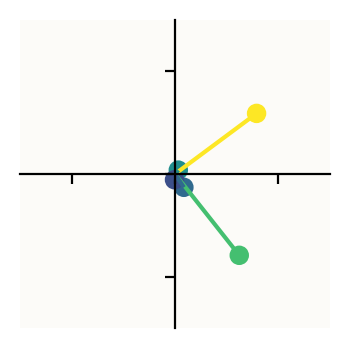

In [114]:
model = LinearToyModel(n=5,m=2)
train(model)
intro_diagram(model)

loss:  tensor(0., grad_fn=<AddBackward0>)
loss:  tensor(0.1242, grad_fn=<AddBackward0>)
loss:  tensor(0.0067, grad_fn=<AddBackward0>)
loss:  tensor(4.0809e-05, grad_fn=<AddBackward0>)
loss:  tensor(0.0027, grad_fn=<AddBackward0>)
loss:  tensor(8.1977e-06, grad_fn=<AddBackward0>)
loss:  tensor(0., grad_fn=<AddBackward0>)
loss:  tensor(1.2641e-07, grad_fn=<AddBackward0>)
loss:  tensor(0., grad_fn=<AddBackward0>)
loss:  tensor(9.5058e-05, grad_fn=<AddBackward0>)


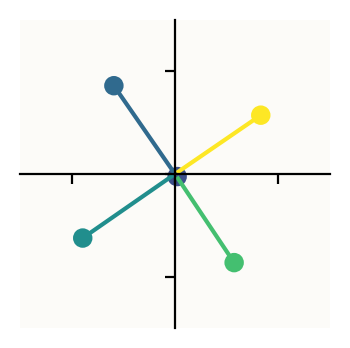

In [115]:
model = ReLUToyModel(n=5,m=2)
train(model)
intro_diagram(model)